# Test policy

Runs one qualitative episode of a trained RL policy on the **real TraceWin environment**, using the
project's normal randomized Gaussian reset (`TEST_RESET_SCALE`, `reset_source="gaussian"` in
`BaseBeamEnv.reset()` -- the same reset `scripts/test.py` uses with `--reset-scale test`), then renders
the episode with every panel `render()` produces (parameters, beam state, score/reward,
parameter-KNN-distance, and start-vs-now delta), plus TraceWin's own particle-distribution plots
(phase space) for both the initial and the final state.

Section 1 is preconfigured for the promoted TD3 checkpoint from
`final_thesis_031_a015_s025_steps300k`, tested for one 30-step episode on TraceWin workspace 1.

This reuses the project's real evaluation building blocks, nothing here is reimplemented:
- `beam_optimization.scripts.common.run_episode` -- the exact same greedy-episode loop
  `scripts/test.py` and `scripts/train_policies.py` use for evaluation.
- `beam_optimization.scripts.test.make_agent` -- the same policy-loading logic `test.py` uses
  (custom algorithms and `sb3_sac` both handled).
- `env.render()` -- the project's real per-episode rendering, shown inline instead of saved to disk.
- `TraceWinEnv.render_initial_beam_distribution()` / `render_final_beam_distribution()` -- the real
  start/end phase-space distributions from TraceWin's own `.dst` output, same as
  `test.py --tracewin-phase-space` for the final one.

This notebook does not train anything and does not modify any checkpoint. It always runs the real
TraceWin simulator (~24 s per step, so a 30-step episode takes roughly 12 minutes) -- live progress is
printed step by step below so it's clear the run is actually advancing.

## 1. Configuration -- TD3, workspace 1, 30 steps

This cell is ready for the selected best policy; execute the notebook from here downward.

In [ ]:
# ---- Agent to test ----
ALGO = "td3"  # one of: sac, td3, ppo, ddpg, a2c, reinforce, trpo, sb3_sac,
              # sac_custom, td3_custom, ppo_custom, ddpg_custom, a2c_custom,
              # reinforce_custom, trpo_custom, mbpo, svg_finale, svg_uniform
POLICY_PATH = "beam_optimization/results/train/rl/final_thesis_031_a015_s025_steps300k/td3/td3_agent.zip"
HIDDEN = [256, 256]  # ignored for ALGO == "sb3_sac" (architecture is loaded from the checkpoint)

# ---- Episode ----
MAX_EP_STEPS = 30  # None -> adige.MAX_STEPS
SEED = 42  # 49  benchmark episode 7: TD3 best observed score = 66.1178274

# ---- TraceWin ----
TRACEWIN_PROJECT = ("beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/"
                    "CB_newMRMS_RFQ_Fields_1.ini")  # workspace 1
TRACEWIN_CALC_DIR = ("beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/"
                     "tracewin_calc_test_td3_30steps")
TRACEWIN_TIMEOUT = 300.0

# ---- Final beam distribution (TraceWin phase space, section 5) ----
MAX_PARTICLES = 40000  # particles plotted from the final .dst file
BINS = 150

# ---- KNN reference dataset (render()'s knn panel + any distance_penalty) ----
# None -> dynamic default (param_knn_distance()'s own fallback: whichever
# numbered env/dataset/<NNN> directory is highest, which drifts every time a
# new dataset is built and may not match what this policy was trained
# against). Pin explicitly here to whatever dataset the surrogate this
# checkpoint was trained through actually used -- dataset 031 for POLICY_PATH above.
KNN_REFERENCE_DATASET = "beam_optimization/env/dataset/031/dataset_all.pt"

In [16]:
import os
from pathlib import Path
import sys
import time

import pandas as pd
from IPython.display import Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
# nbconvert/Jupyter set the working directory to this notebook's own folder
# (beam_optimization/results/), not the repo root -- switch back so every
# relative path in the config cell above (POLICY_PATH, TRACEWIN_PROJECT, ...)
# resolves the same way it would from a commands/*.sh script.
os.chdir(REPO_ROOT)

from beam_optimization.config.adige import (
    MAX_STEPS, REWARD_SCORE_SCALE, TERMINAL_FAILURE_REWARD, TEST_RESET_SCALE,
)
from beam_optimization.config.paths import DEFAULT_TRACEWIN_INI
from beam_optimization.env.tracewin_env import TraceWinEnv
from beam_optimization.scripts.common import run_episode
from beam_optimization.scripts.test import make_agent

max_ep_steps = MAX_EP_STEPS or MAX_STEPS

print(f'ALGO={ALGO}  POLICY_PATH={POLICY_PATH}')
print(f'max_ep_steps={max_ep_steps}  seed={SEED}')

# Pin the KNN reference dataset used by render()'s knn panel (and any
# distance_penalty) to KNN_REFERENCE_DATASET instead of letting
# param_knn_distance() fall back to its own default (the highest-numbered
# env/dataset/<NNN> directory at import time, which silently drifts as new
# datasets get built). resolve_dataset()/param_knn_distance() only load the
# default when their process-wide cache is still empty, so priming that
# cache here -- once, before any render() call -- makes every later call in
# this notebook use KNN_REFERENCE_DATASET without changing param_knn_distance()
# itself or any other script/notebook's behavior.
if KNN_REFERENCE_DATASET is not None:
    from beam_optimization.env.dataset import dataset as _dataset_module
    from beam_optimization.env.dataset.dataset import BeamDataset

    knn_reference_path = Path(KNN_REFERENCE_DATASET)
    if not knn_reference_path.is_absolute():
        knn_reference_path = REPO_ROOT / knn_reference_path
    _dataset_module._default_dataset_cache = BeamDataset.load(knn_reference_path)
    print(f'KNN reference dataset pinned to: {knn_reference_path}')
else:
    print('KNN reference dataset: dynamic default (highest-numbered env/dataset/<NNN>)')


def make_progress_callback(total_steps):
    """Build a run_episode(step_callback=...) that prints live progress.

    run_episode() (scripts/common.py) already calls this once after reset()
    (step_idx=0) and once after every env.step() -- printing here (with
    flush=True) is enough to see each step land in the notebook output as it
    happens, instead of waiting silently for the whole episode to finish
    (useful on TraceWin, where each step is ~20-30 s of real simulation).
    """
    start = time.time()

    def callback(step_idx, env, info, done):
        elapsed = time.time() - start
        score = info.get('score', float('nan'))
        tag = 'reset' if step_idx == 0 else f'step {step_idx:>2}/{total_steps}'
        status = '  <- episode done' if done else ''
        print(f'{tag:<12} elapsed={elapsed:>6.1f}s  score={score:>10.4g}{status}', flush=True)

    return callback


def make_agent_any(algo, policy_path, obs_dim, hidden, env):
    """Like scripts.test.make_agent(), but also handles svg_finale/svg_uniform/mbpo.

    scripts/test.py's make_agent() (used by the real `test` CLI command too)
    only supports Stable Baselines3 + the plain custom algorithms -- SVG/MBPO
    checkpoints need a surrogate + dataset to reconstruct the policy object
    first (see scripts/benchmark.py's make_policy_agent(), which this mirrors),
    so tracewin_agents_benchmark.ipynb's qualitative-test section explicitly
    skips them too ("use the numerical benchmark for this agent type"). This
    notebook wants the full render()/phase-space treatment for those agents as
    well, so it does the extra reconstruction step locally instead of skipping.
    """
    if algo not in ("svg_finale", "svg_uniform", "mbpo"):
        return make_agent(algo, policy_path, obs_dim, hidden, env=env)

    from beam_optimization.algorithms import make_custom_agent
    from beam_optimization.algorithms.model_based.svg import SVGAgent
    from beam_optimization.config.adige import (
        N_OUTPUT_STAGES, N_PARAMS, PARAM_KEYS, action_bounds, default_params,
    )
    from beam_optimization.config.paths import default_dataset_path, default_single_surrogate_model
    from beam_optimization.env.dataset import BeamDataset
    from beam_optimization.env.surrogate_env.surrogate.model.modular_mlp import ModularMLP

    bounds = action_bounds()
    if algo == "mbpo":
        # "mbpo" checkpoints are the inner SAC saved by train_dyna -- no
        # surrogate/dataset needed to reconstruct this one.
        agent = make_custom_agent("sac_custom", obs_dim, N_PARAMS, bounds, hidden_dims=hidden)
    else:
        surrogate = ModularMLP.load(default_single_surrogate_model())
        surrogate.eval()
        dataset = BeamDataset.load(default_dataset_path())
        stage_weights = [1.0] * N_OUTPUT_STAGES if algo == "svg_uniform" else None
        agent = SVGAgent(
            surrogate=surrogate, dataset=dataset, obs_dim=obs_dim, act_dim=N_PARAMS,
            action_bounds=bounds, param_keys=PARAM_KEYS, default_params=default_params(),
            hidden_dims=tuple(hidden), n_step=env.max_steps, stage_weights=stage_weights,
        )
    agent.load(policy_path)
    return agent

ALGO=td3  POLICY_PATH=beam_optimization/results/train/rl/final_thesis_031_a015_s025_steps300k/td3/td3_agent.zip
max_ep_steps=30  seed=49
[BeamDataset] 125,844 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_all.pt
KNN reference dataset pinned to: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_all.pt


## 1b. Reward function this checkpoint was trained with

Every training run writes a `summary.json` next to its checkpoint, recording the exact
regularization weights used for that run (`train_policies.py`) and the physical score-function
metadata in effect at training time (`score_function_metadata()`). This reads that file back --
nothing here is reimplemented, and it doesn't require the environment/agent built below.

In [17]:
import json

# Checkpoints live at <run_dir>/<algo>/<algo>_agent.{pt,zip}; summary.json is
# written one level up, at <run_dir>/summary.json.
summary_path = Path(POLICY_PATH).resolve().parent.parent / "summary.json"

if not summary_path.is_file():
    print(
        f"No summary.json found at {summary_path} -- this checkpoint's training-run "
        "metadata isn't available (older run, or a non-standard output layout). "
        "Skipping this section."
    )
else:
    summary = json.loads(summary_path.read_text())
    regularization = summary.get("training_reward_regularization", {})
    score_meta = summary.get("score_function", {})

    display(Markdown(f"**Training run summary:** `{summary_path}`"))

    display(Markdown("### Reward regularization weights used for this run"))
    display(pd.DataFrame({"weight": regularization}))

    display(Markdown("### Physical score function (recorded at training time)"))
    display(Markdown(
        f"- `{score_meta.get('name', '?')}` (v{score_meta.get('version', '?')})\n"
        f"- {score_meta.get('formula', '?')}\n"
        f"- All-particles-lost sentinel: `npart_ratio <= "
        f"{score_meta.get('all_particles_lost_npart_ratio', '?')}` -> "
        f"score = `{score_meta.get('error_score', '?')}`"
    ))
    display(pd.DataFrame({
        "weight": score_meta.get("weights", {}),
        "reference": score_meta.get("references", {}),
    }))

    # Human-readable versions of the penalty-term names used in the formula
    # below, matching BaseBeamEnv.step()/_control_penalties()/_distance_penalty().
    term_labels = {
        "distance_penalty_weight": "distance_penalty",
        "action_penalty_weight": "action_penalty",
        "action_smoothness_penalty_weight": "action_smoothness_penalty",
        "score_regression_penalty_weight": "score_regression_penalty",
    }
    active_terms = "".join(
        f"      - {weight:.4g} * {term_labels.get(name, name)}\n"
        for name, weight in regularization.items()
        if weight
    ) or "      (all regularization weights are 0 for this run -- pure score reward)\n"

    display(Markdown(
        "### Assembled per-step RL reward (`BaseBeamEnv.step()`)\n"
        "```\n"
        f"reward = score / {REWARD_SCORE_SCALE:g}\n"
        f"{active_terms}"
        "```\n"
        f"except on a terminal physical failure (all particles lost), where "
        f"`reward = {TERMINAL_FAILURE_REWARD:g}` outright -- no score or penalty terms "
        "are computed for that step.\n\n"
        "Penalty terms (each already includes its weight above):\n"
        "- **distance_penalty**: sensitivity-normalized k-NN distance of the current "
        "parameters to the reference dataset (same metric as `render()`'s knn panel)\n"
        "- **action_penalty**: `mean(normalized_action^2)` -- quadratic cost on this "
        "step's action magnitude\n"
        "- **action_smoothness_penalty**: `mean(normalized_(action - previous_action)^2)` "
        "-- quadratic cost on how much the action changed from the previous step\n"
        "- **score_regression_penalty**: `max(0, previous_score - score) / "
        f"{REWARD_SCORE_SCALE:g}` -- only charged when the score *drops* step to step"
    ))

**Training run summary:** `/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/train/rl/final_thesis_031_a015_s025_steps300k/summary.json`

### Reward regularization weights used for this run

,weight
distance_penalty_weight,0.02
action_penalty_weight,0.15
action_smoothness_penalty_weight,0.25
score_regression_penalty_weight,5.00


### Physical score function (recorded at training time)

- `adige_linear_beam_quality` (v1)
- ERROR_SCORE if npart_ratio <= ALL_PARTICLES_LOST_NPART_RATIO; otherwise linear transmission reward minus emittance, offset, angle, and size penalties
- All-particles-lost sentinel: `npart_ratio <= 0.0` -> score = `-999.0`

,weight,reference
npart_ratio,100.0,NaN
emittance,10.0,NaN
offset,1.0,NaN
angle,1.0,NaN
size,1.0,NaN
ex,NaN,0.05
ey,NaN,0.05
x0,NaN,0.00
y0,NaN,0.00
x'0,NaN,0.00


### Assembled per-step RL reward (`BaseBeamEnv.step()`)
```
reward = score / 100
      - 0.02 * distance_penalty
      - 0.15 * action_penalty
      - 0.25 * action_smoothness_penalty
      - 5 * score_regression_penalty
```
except on a terminal physical failure (all particles lost), where `reward = -10` outright -- no score or penalty terms are computed for that step.

Penalty terms (each already includes its weight above):
- **distance_penalty**: sensitivity-normalized k-NN distance of the current parameters to the reference dataset (same metric as `render()`'s knn panel)
- **action_penalty**: `mean(normalized_action^2)` -- quadratic cost on this step's action magnitude
- **action_smoothness_penalty**: `mean(normalized_(action - previous_action)^2)` -- quadratic cost on how much the action changed from the previous step
- **score_regression_penalty**: `max(0, previous_score - score) / 100` -- only charged when the score *drops* step to step

## 2. Build the TraceWin environment and load the agent

In [18]:
project_file = Path(TRACEWIN_PROJECT) if TRACEWIN_PROJECT else DEFAULT_TRACEWIN_INI
calc_dir = Path(TRACEWIN_CALC_DIR) if TRACEWIN_CALC_DIR else project_file.parent / 'tracewin_calc_test'
env = TraceWinEnv(
    project_file=str(project_file), calc_dir=str(calc_dir),
    max_steps=max_ep_steps, timeout=TRACEWIN_TIMEOUT, reset_scale=TEST_RESET_SCALE,
    capture_reset_distribution=True,  # keep the initial part_dtl1.dst in memory for section 5
)
print(f'TraceWinEnv  project={project_file}  calc_dir={calc_dir}')

obs_dim = env.observation_space.shape[0]
agent = make_agent_any(ALGO, POLICY_PATH, obs_dim, HIDDEN, env=env)
print(f'Loaded {ALGO} from {POLICY_PATH}  (obs_dim={obs_dim})')

TraceWinEnv  project=beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/CB_newMRMS_RFQ_Fields_1.ini  calc_dir=beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/tracewin_calc_test_td3_30steps
Loaded td3 from beam_optimization/results/train/rl/final_thesis_031_a015_s025_steps300k/td3/td3_agent.zip  (obs_dim=27)


## 3. Run the benchmark reset that produced TD3's maximum score

The 30-step benchmark reached TD3's maximum score (**66.1178274**) in episode index 7,
at step 30. With benchmark base seed 42, that episode uses `SEED = 42 + 7 = 49`.
`reset_options=None` keeps the normal randomized evaluation reset, so `BaseBeamEnv.reset()`
reconstructs the same initial parameter draw as `default + Normal(0,
TEST_RESET_SCALE * sensitivity)`.

In [12]:
result = run_episode(
    env, agent, seed=SEED, reset_options=None,
    step_callback=make_progress_callback(max_ep_steps),
)

display(Markdown('\n\n'.join([
    '### Episode summary',
    f"- Final score: **{result['final_score']:.6g}**",
    f"- Total reward: **{result['total_reward']:.6g}**",
    f"- Steps taken: **{len(result['steps'])}** / {max_ep_steps}",
    '- Final beam features: ' + ', '.join(
        f'{name}={value:.6g}' for name, value in result['final_features'].items()
    ),
])))

reset        elapsed=  13.0s  score=     15.31
step  1/30   elapsed=  25.7s  score=     16.77
step  2/30   elapsed=  38.5s  score=     21.15
step  3/30   elapsed=  51.3s  score=      24.3
step  4/30   elapsed=  64.0s  score=     24.22
step  5/30   elapsed=  76.9s  score=     26.04
step  6/30   elapsed=  89.5s  score=     26.68
step  7/30   elapsed= 102.6s  score=     26.92
step  8/30   elapsed= 115.4s  score=     27.91
step  9/30   elapsed= 128.1s  score=     28.45
step 10/30   elapsed= 141.1s  score=     29.06
step 11/30   elapsed= 153.8s  score=     31.45
step 12/30   elapsed= 166.4s  score=     34.33
step 13/30   elapsed= 179.1s  score=     37.57
step 14/30   elapsed= 191.8s  score=      41.2
step 15/30   elapsed= 204.7s  score=     46.25
step 16/30   elapsed= 217.2s  score=     53.01
step 17/30   elapsed= 229.4s  score=     60.03
step 18/30   elapsed= 241.4s  score=     59.77
step 19/30   elapsed= 254.1s  score=     62.78
step 20/30   elapsed= 266.1s  score=     63.27
step 21/30   

### Episode summary

- Final score: **64.3399**

- Total reward: **13.695**

- Steps taken: **30** / 30

- Final beam features: npart_ratio=0.6753, x0=1.94024, y0=0.0627658, SizeX=4.29628, SizeY=3.31586, ex=0.056687, ey=0.072476, x'0=-2.93488, y'0=-0.348422

## 4. Render the episode

Same panels `render()` produces everywhere else in the project: one line per machine parameter, one
per (beam feature, observed stage), score/reward and parameter-KNN-distance trends over the whole
episode, plus a "delta" bar chart (final observed stage + score, now vs. right after `reset()`,
green/red/gray for improved/worsened/unchanged).

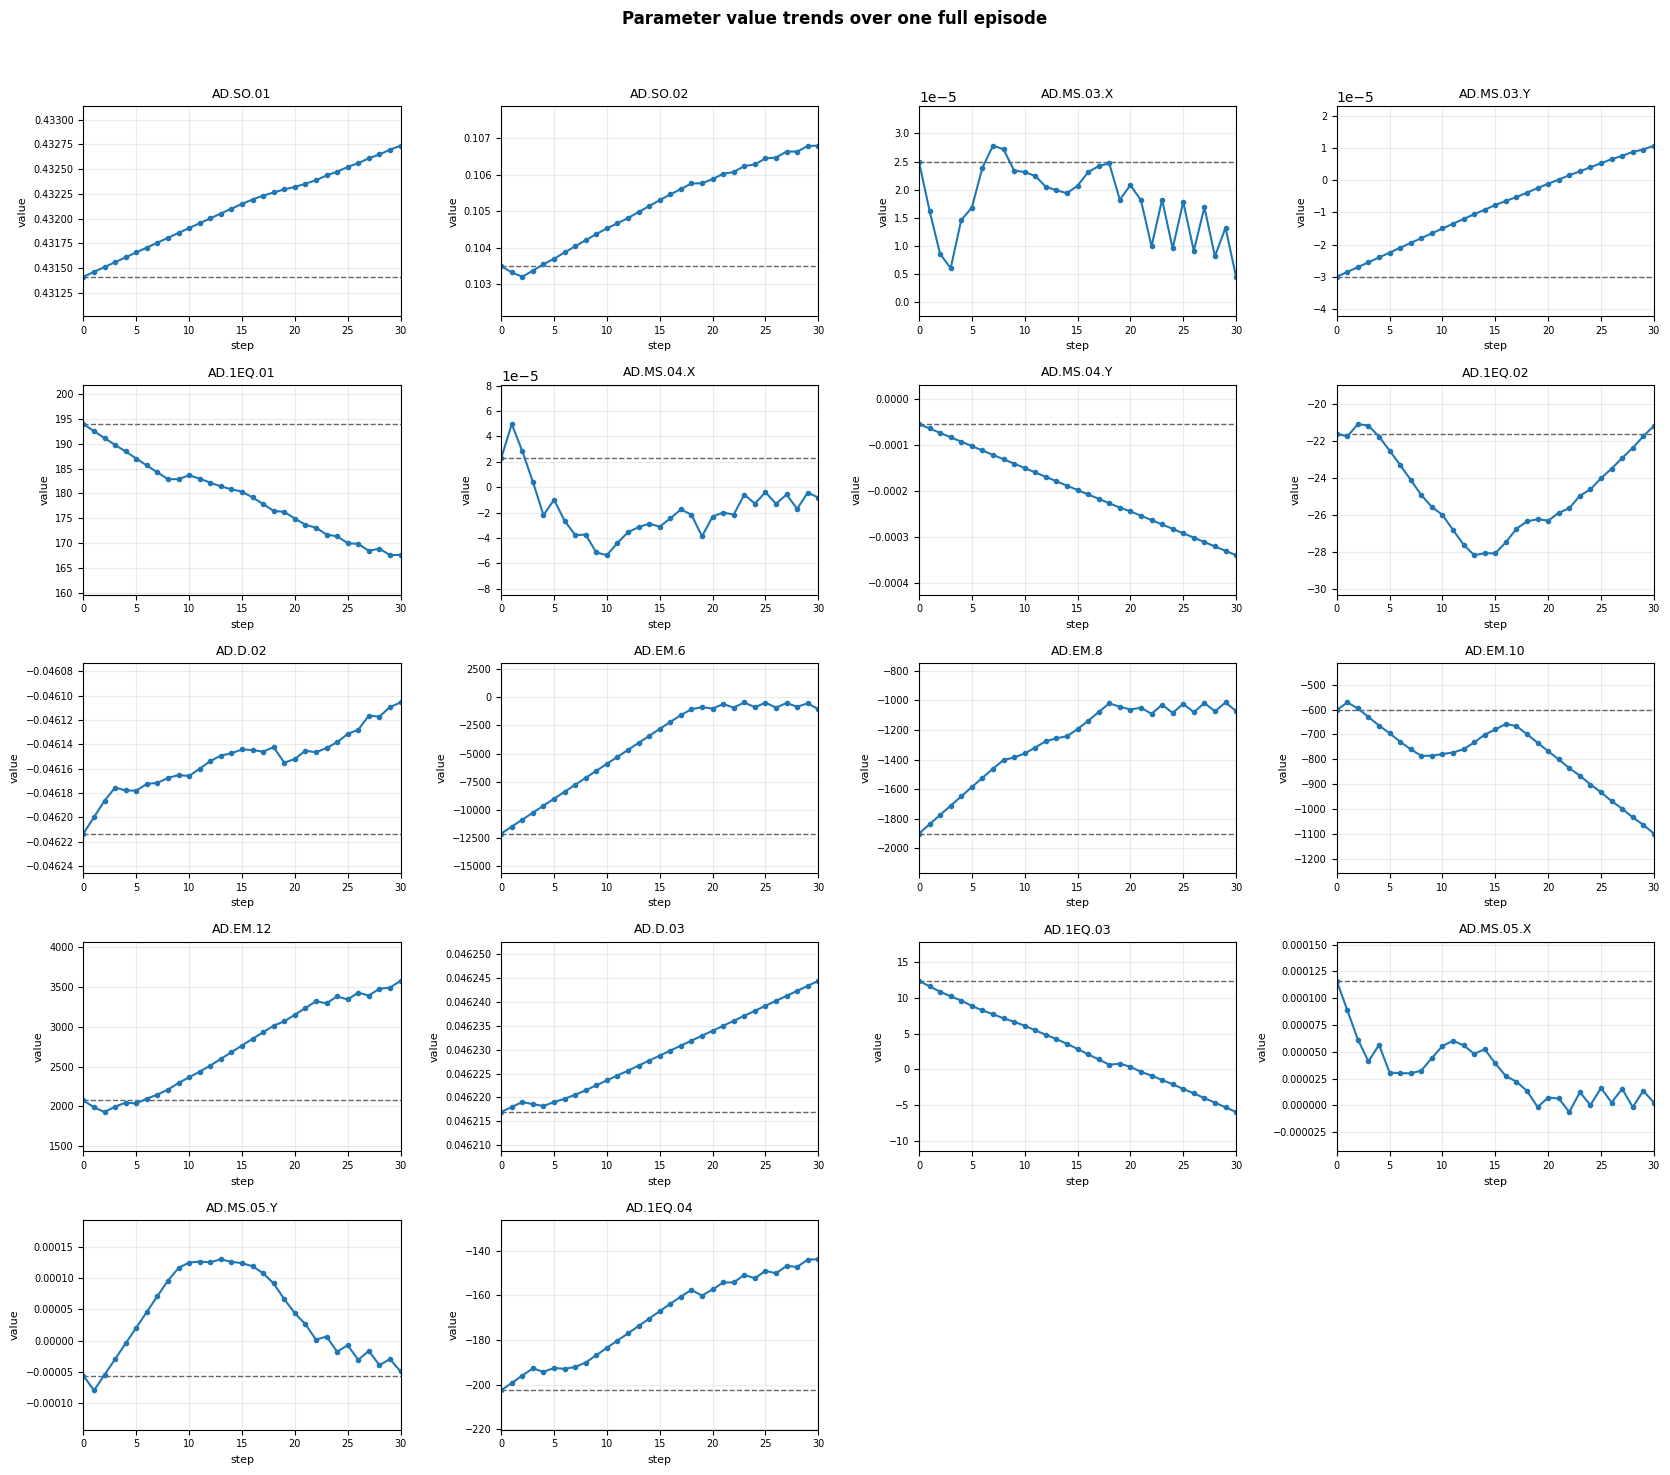

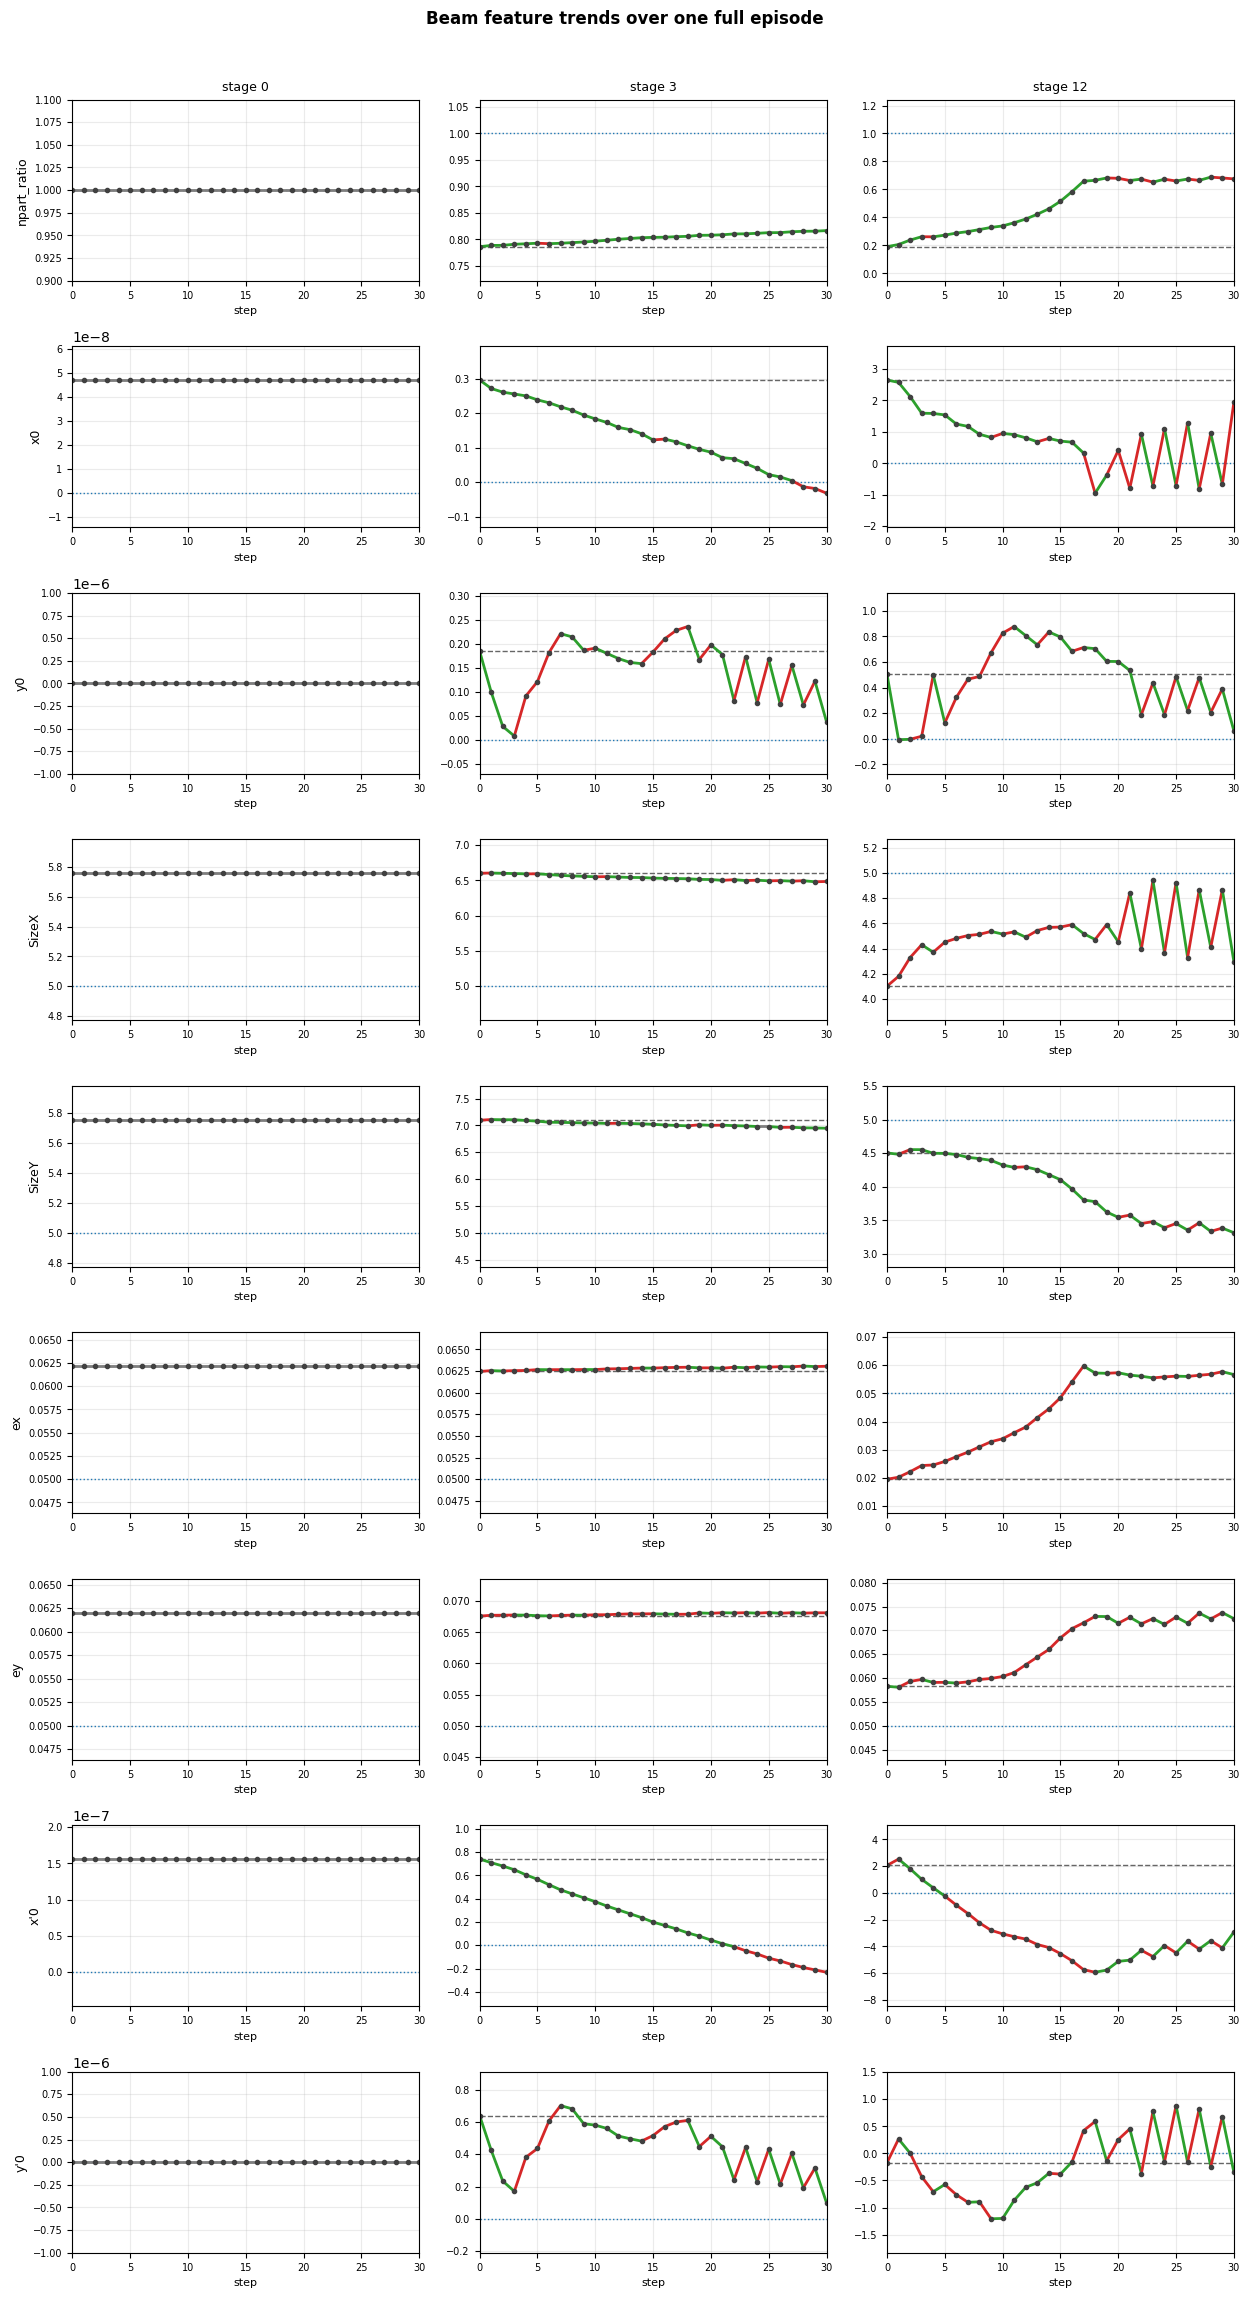

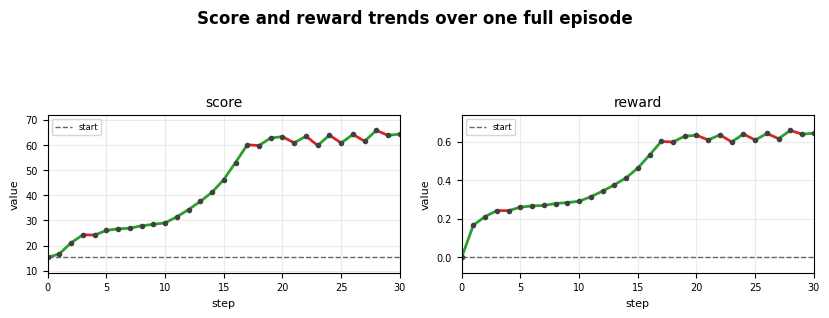

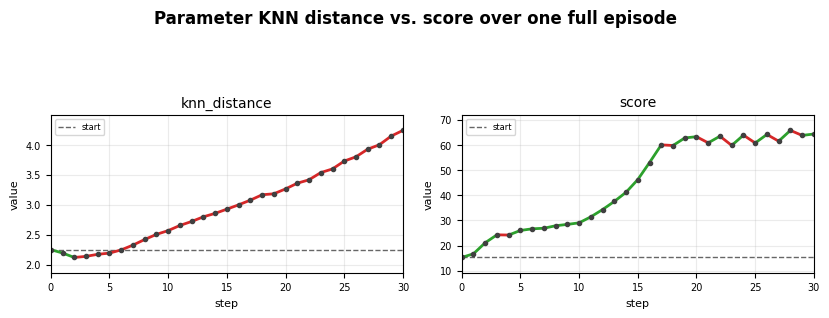

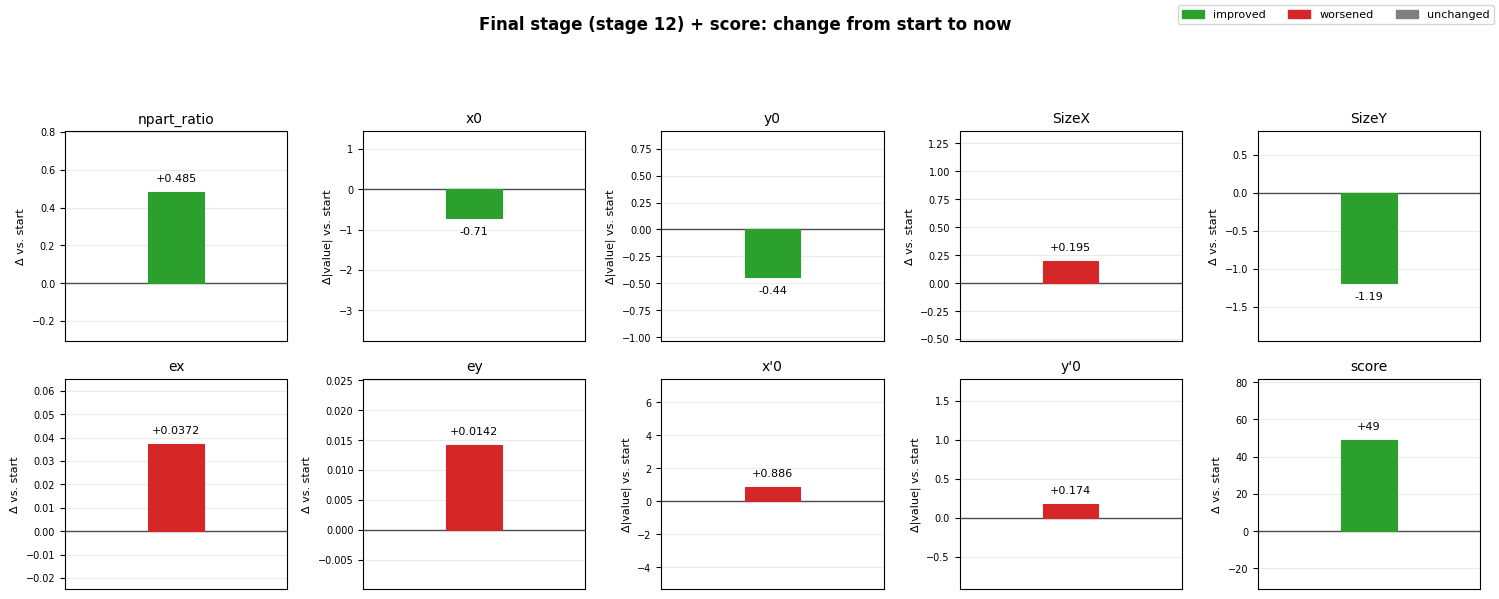

In [13]:
figures = env.render()

## 5. Beam distribution (TraceWin phase space): start vs. end

`render()` above plots feature *trends* over the episode; these are the actual **particle
distributions** from TraceWin's own output (`part_dtl1.dst` in the calc dir) -- the same x-y/x-x'/y-y'
phase-space panels plus the beam-state/score table as
[`visualize_distributions.ipynb`](../env/tracewin_env/tracewin/visualize_distributions.ipynb) and
`visualize_distributions_python_run.ipynb`, via the shared
`plot_tracewin_distribution_with_state()` helper, so a GUI run, a direct `TraceWinSimulator` run, and
this RL episode's steps all render identically for the same beam state.

Two snapshots are shown, in this order:
1. **Initial** (`TraceWinEnv.render_initial_beam_distribution()`) -- the state right after `reset()`,
   before the agent has taken any action. This only works because `env` was built above with
   `capture_reset_distribution=True`, which keeps that first `part_dtl1.dst` in memory (it would
   otherwise be overwritten by the very first `step()`).
2. **Final** (`TraceWinEnv.render_final_beam_distribution()`) -- the state after the last step of the
   episode, read live from the calc dir.

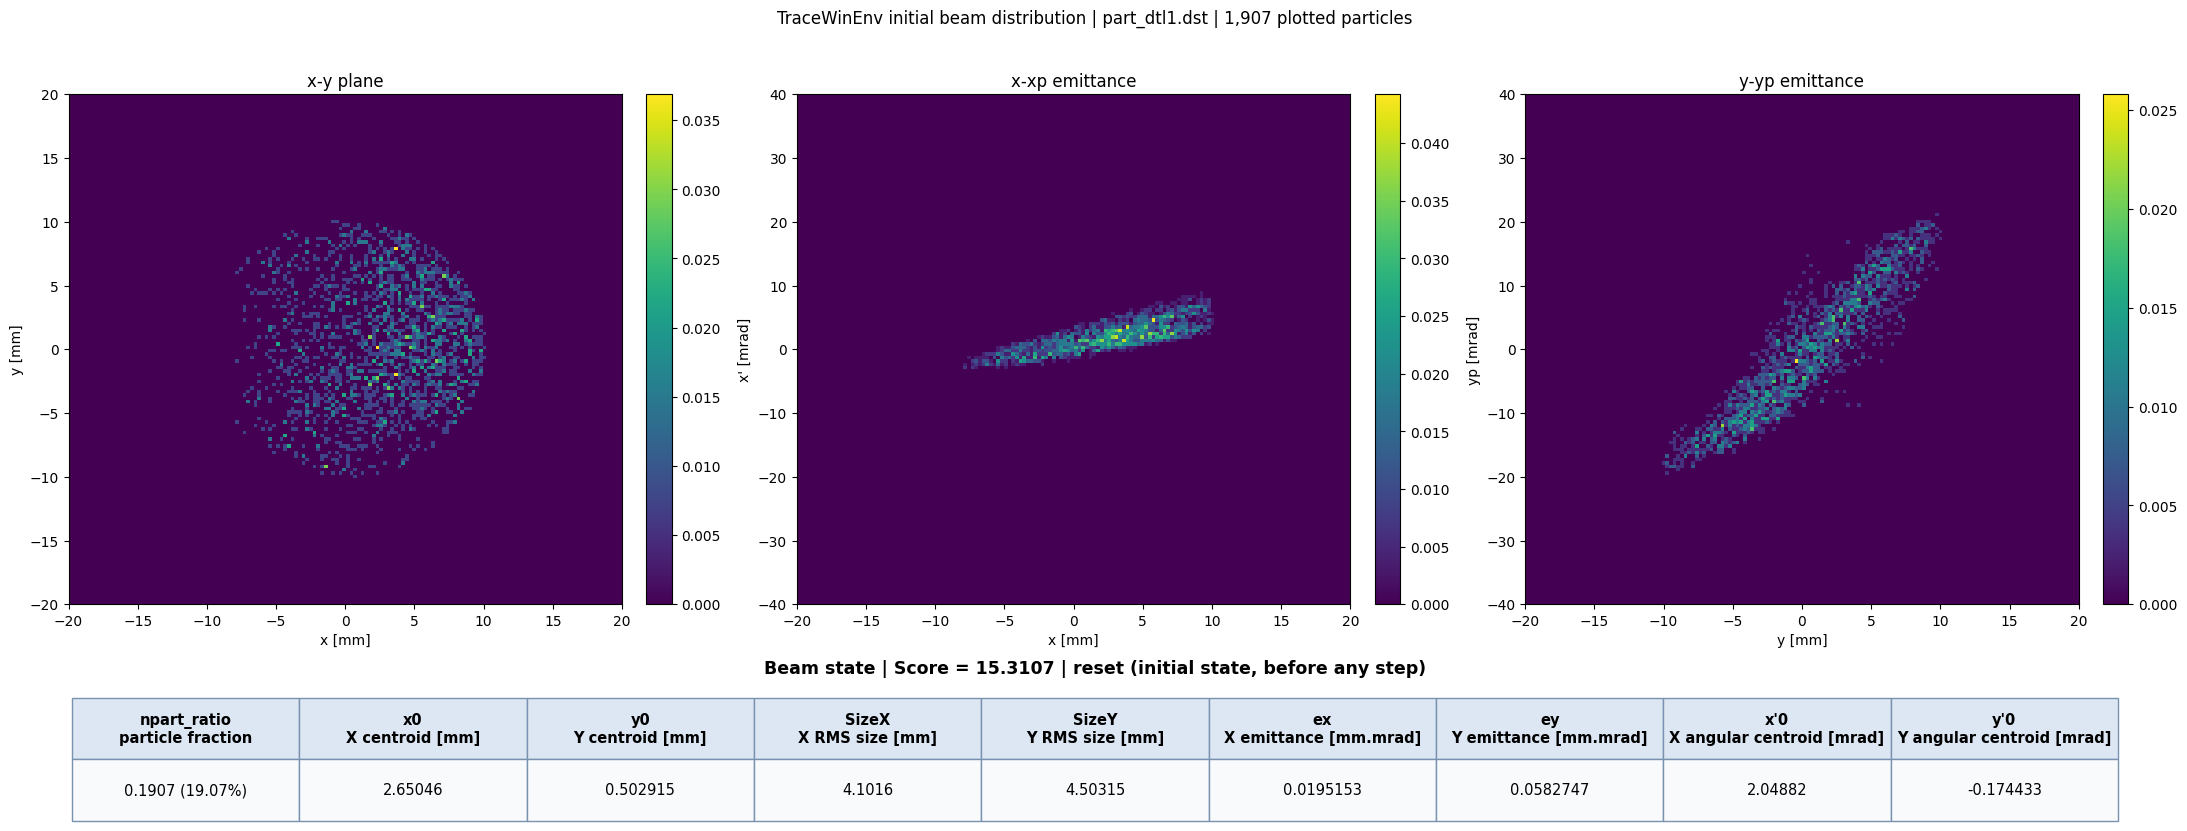

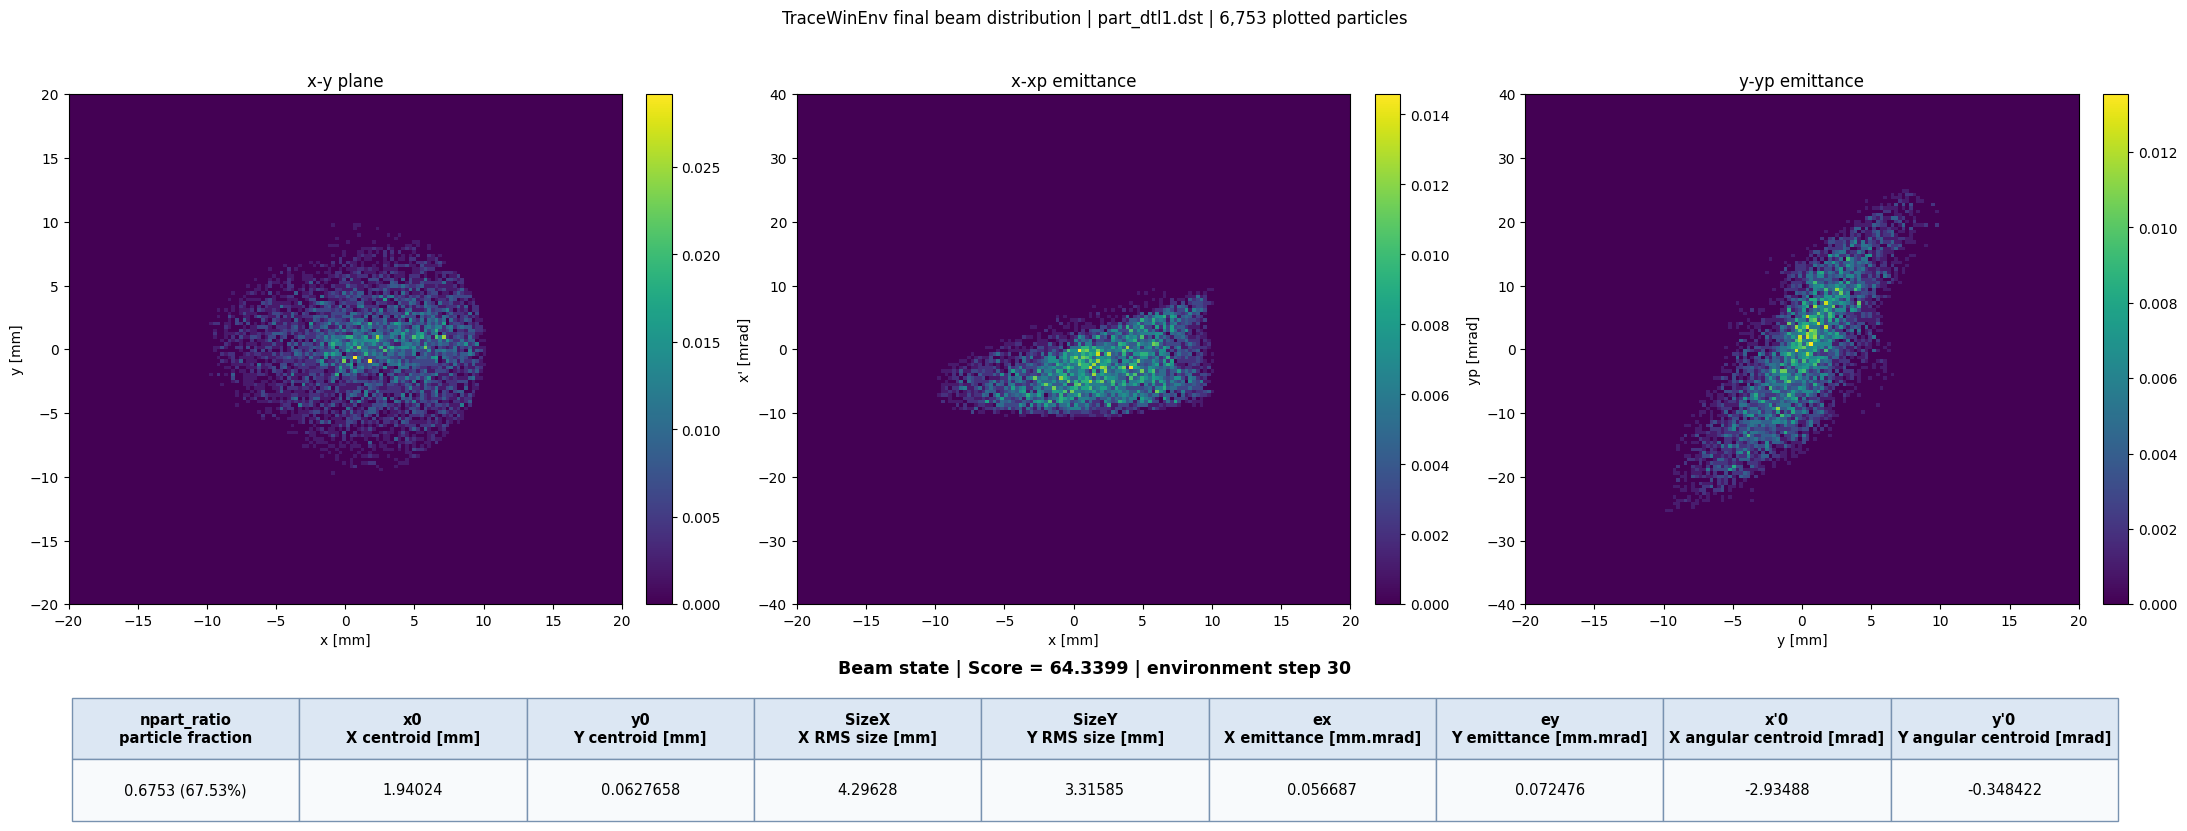

In [14]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive.*')
    initial_phase_space_fig = env.render_initial_beam_distribution(
        max_particles=MAX_PARTICLES, bins=BINS,
    )
    final_phase_space_fig = env.render_final_beam_distribution(
        max_particles=MAX_PARTICLES, bins=BINS,
    )

## Where this fits

- For a numeric comparison across many episodes/policies, use `scripts/benchmark.py`
  (`python -m beam_optimization benchmark ...`) instead of this notebook.
- This notebook is the interactive equivalent of `scripts/test.py --env tracewin --reset-scale test`
  (see `commands/test_policy_tracewinEnv.sh`), with live per-step progress printed as the episode
  runs.